# Learning Uncertainty Sets

In [1]:
import cvxpy as cp
import scipy as sc
import numpy as np
import numpy.random as npr
import torch
from sklearn import datasets
import pandas as pd
import lro
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "text.usetex":True,
    
    "font.size":18,
    "font.family": "serif"
})
colors = ["tab:blue", "tab:green", "tab:orange", 
          "blue", "tab:purple", "tab:brown", "tab:pink", "tab:grey", "tab:olive"]

In [2]:
def pareto_frontier(Xs, Ys, maxX = False, maxY = False):
# Sort the list in either ascending or descending order of X
    Xs = np.array(Xs)
    Ys = np.array(Ys)
    myList = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX)
# Start the Pareto frontier with the first value in the sorted list
    p_front = [myList[0]]    
# Loop through the sorted list
    for pair in myList[1:]:
        if maxY: 
            if pair[1] >= p_front[-1][1]: # Look for higher values of Y…
                p_front.append(pair) # … and add them to the Pareto frontier
        else:
            if pair[1] <= p_front[-1][1]: # Look for lower values of Y…
                p_front.append(pair) # … and add them to the Pareto frontier
# Turn resulting pairs back into a list of Xs and Ys
    p_frontX = [pair[0] for pair in p_front]
    p_frontY = [pair[1] for pair in p_front]
    return p_frontX, p_frontY

## Formulating the uncertainty set

We now formulate the uncertainty set slightly differently, where data and a loss function is passed as parameters instead of the uncertainty set parameters. The parameters for the uncertainty set, $A$ and $b$, will now be trained through differentiable optimization. 


### Ellipsoidal uncertainty: $\{u \mid \| Au + b \|_p \leq 1 \}$ 

- $p$ : integer, optional  
  * Order of the norm. Default 2.
- data : np.array  
  * An array of uncertainty realizations, where each row is one realization.
- loss : function
  * The loss function used to train the uncertainty set. 


### Mean Robust uncertainty: $\{ u = (v_1,\dots,v_K)  \mid  \sum_{k=1} ^K w_k \| A_k(v_k - \bar{d}_k) \|_p^{\text{power}} \le \rho \}$ 

- $K$: int
  * Number of clusters. Default 1.
- $p$ : integer, optional  
  * Order of the norm. Default 2.
- power: integer, optional
  * Power of the norm. Default 1. 
- data : np.array  
  * An array of uncertainty realizations, where each row is one realization.
- loss : function
  * The loss function used to train the uncertainty set. 


### Box uncertainty: $\{ u \mid\| Au + b \|_\infty \leq 1 \}$ 

- data : np.array  
  * An array of uncertainty realizations, where each row is one realization.
- loss : function
  * The loss function used to train the uncertainty set. 

### Budget uncertainty: 

1. train the box portion only: $\{u \mid \| Au + b \|_\infty \leq 1, \| u \|_1 \leq \rho_2\}$ 
2. train the 1-norm portion only: $\{u \mid \| u \|_\infty \leq \rho_1, \| Au + b \|_1 \leq 1\}$ 
- train_box: boolean, optional
  * If True, train the box portion only. Default True. 
- $\rho_1$ : float, optional
  * Box scaling. Default 1.0.
- $\rho_2$ : float, optional
  * 1-norm scaling. Default 1.0.
- data : np.array  
  * An array of uncertainty realizations, where each row is one realization.
- loss : function
  * The loss function used to train the uncertainty set.
  

### Formulating the loss function

The loss function passed into the uncertainty set must be a function that returns torch tensors with gradient information. The function must take in as inputs all the variables defined in the Robust Problem, as well as the data used to evaluate the loss. There may also be other inputs to the function, depending on the type of loss.  
An example of a violation loss is 
$$
\mathcal{L}(\mathcal{D}, x) = f(x)  + \frac{\lambda }{N}\sum_{i=1}^{N} g(d_i,x)_+,
$$
where $\mathcal{D}$ is the dataset, $\lambda$ is the weight on the violation loss, $N$ is the total number of datapoints in the dataset, and $d_i$ is sample $i$ of the dataset. 

### Training the uncertainty set

To train the uncertainty set, after setting up the robust problem, call `problem.train()`, with optional parameters to control whether to train only $\epsilon$ or both $A$ and $b$, the total number of iterations, the learning rate of the problem, the optimizer to use, and initial values for $A$ and $b$. 

The function will return a pandas DataFrame with information on the iterates, as well as the reformulated problem.


### Example 1: Linear Portfolio


### Example 4: Affine Adjustable Robust Optimization: Inventory management

We solve the robust optimization problem given as 
\begin{equation*}
	\begin{array}{ll}
		\text{minimize} & L\\
		\text{subject to} & -r^Ty^0 - r^TYu + (t+h)^Ts \le L, \quad \forall u\in \mathcal{U}(\mathcal{D}_N,\theta)\\
		& y^0_i + y_i^Tu\leq s_i, \quad i = 1, \dots, N, \quad \forall u\in \mathcal{U}(\mathcal{D}_N,\theta)\\
		& y^0_i + y_i^Tu \leq d_i^0 + q_i^Tu, \quad i = 1, \dots, N, \quad \forall u\in \mathcal{U}(\mathcal{D}_N,\theta)\\
			& \mathbf{1}^Ts = C\\
			& s \leq c\\
			& s \geq 0.
	\end{array}
\end{equation*}


In [86]:
def data_scaled(N, m, scale):
    R = np.vstack([np.random.normal(
        i*0.03*scale, np.sqrt((0.02**2+(i*0.025)**2)), N) for i in range(1, m+1)])
    return (R.transpose())

def data_modes(N, m, scales):
    modes = len(scales)
    d = np.zeros((N+100, m))
    weights = int(np.ceil(N/modes))
    for i in range(modes):
        d[i*weights:(i+1)*weights,
          :] = data_scaled(weights, m, scales[i])
    return d[0:N, :]

def loss(L,y,Y,s,alpha, data,mu=1000,l=10000,quantile = 0.95, target = -0.1):
    sums = 0
    totsum = 0
    Nsample = data.shape[0]
    for i in range(Nsample):
        sums += torch.sum(torch.maximum(y + Y@data[i] - s-alpha, torch.tensor(0.,requires_grad = True)))
        sums += torch.sum(torch.maximum(y + Y@data[i] - torch.tensor(d) - torch.tensor(Q)@data[i] - alpha, torch.tensor(0.,requires_grad = True)))
        sums += torch.maximum(-torch.tensor(r)@y - torch.tensor(r)@Y@data[i] + torch.tensor(t+ h)@s - L - alpha, torch.tensor(0.,requires_grad = True))

        newsums = torch.sum(torch.where(torch.maximum(y + Y@data[i] - s, torch.tensor(0.,requires_grad = True))>=0.001,torch.tensor(1.), torch.tensor(0.)))
        newsums += torch.sum(torch.where(torch.maximum(y + Y@data[i] - torch.tensor(d) - torch.tensor(Q)@data[i], torch.tensor(0.,requires_grad = True))>=0.001,torch.tensor(1.), torch.tensor(0.)))
        newsums += torch.where(torch.maximum(-torch.tensor(r)@y - torch.tensor(r)@Y@data[i] + torch.tensor(t+ h)@s - L, torch.tensor(0.,requires_grad = True))>=0.01, torch.tensor(1.), torch.tensor(0.))
        totsum += newsums/(2*10+1)
    sums = (sums/((1-quantile)*(2*10+1)*Nsample)) + alpha
    return L + torch.tensor(l)*(sums - torch.tensor(target)) + torch.tensor(mu/2)*(sums - torch.tensor(target))**2, L, totsum/Nsample, sums.detach().numpy()

#torch.tensor(totsum/Nsample)
n = 10
m = 4
# data = np.random.normal(0,3,(400,m))
# data = np.load("invdat7.npy")


In [120]:
# data = np.load("invdat8.npy")
# data = data[:250]
n = 10
m = 4
#data = np.random.normal(0,3,(400,m))
# data = data_modes(300,m,[10,20,30])
data = np.load("invdat8.npy")
#restate the ellipsoidal set
u = lro.UncertainParameter(m,
                                uncertainty_set = lro.Ellipsoidal(p=2, 
                                                                  rho=1., data =data, loss =loss))
# K = 1
# u = lro.UncertainParameter(m,
#                                 uncertainty_set = lro.MRO(p=2, K = K,
#                                                                   rho=1., data =data, loss =loss, uniqueA = True))
# Astart = u.uncertainty_set._init_A
# formulate cvxpy variable
L = cp.Variable()
s = cp.Variable(n)
y = cp.Variable(n)
Y = cp.Variable((n,m))

# formulate problem constants
C = 2000
# c = np.random.uniform(300,500,n)
# Q = np.random.uniform(-2,2,(n,m))
# d = np.random.uniform(100,200,n)
# t = np.random.uniform(1,3,n)
# h = np.random.uniform(1,3,n)
# r = np.random.uniform(20,40,n)
# np.save("c.npy", c)
# np.save("Q.npy", Q)
# np.save("d.npy", d)
# np.save("t.npy", t)
# np.save("h.npy", h)
# np.save("r.npy", r)


# formulate objective
objective = cp.Minimize(L)

# formulate constraints
constraints = [-r@y - r@Y@u + (t+h)@s <= L]
for i in range(n):
    constraints += [y[i]+Y[i]@u <= s[i]]
    constraints += [y[i]<= d[i]+ (Q[i] - Y[i])@u]
constraints += [np.ones(n)@s == C]
constraints += [s <=c, s >=0]

# formulate Robust Problem
prob = lro.RobustProblem(objective, constraints)
target = -0.2
# solve
s = 5

init = sc.linalg.sqrtm(sc.linalg.inv(np.cov(data.T)))
init_bval = -init@np.mean(data, axis=0)
result1 = prob.train(lr = 0.000001, step=500, momentum = 0.8, optimizer = "SGD", seed = s, init_A = 0.3*init, init_b = 0.3*init_bval, fixb = False, init_lam = 100, target_cvar = target, init_alpha = -0.05, mu_multiplier = 1.01)
df1 = result1.df
A_fin = result1.A
b_fin = result1.b

result3 = prob.train(eps = True, lr = 0.00001, step=500, momentum = 0.8, optimizer = "SGD", seed = s, init_A = 0.3*init, init_b =0.3*init_bval,  init_lam = 100, target_cvar = target, init_alpha = -0.05, mu_multiplier = 1.01)
df_r2 = result3.df

# Grid search epsilon
result4 = prob.grid(epslst = np.linspace(0.01, 3, 40), init_A = 0.3*init, init_b = 0.3*init_bval, seed = s, init_alpha = 0.)
dfgrid = result4.df

result5 = prob.grid(epslst = np.linspace(0.01,3, 40), init_A = A_fin, init_b = b_fin, seed = s, init_alpha = 0.)
dfgrid2 = result5.df

In [135]:
# df1.to_csv("df1_inv")
# df_r2.to_csv("df_r2_inv")
# dfgrid.to_csv("dfgrid_inv")
# dfgrid2.to_csv("dfgrid2_inv")
# np.save("c1.npy", c)
# np.save("Q1.npy", Q)
# np.save("d1.npy", d)
# np.save("t1.npy", t)
# np.save("h1.npy", h)
# np.save("r1.npy", r)
# np.save("invdat8.npy", data)

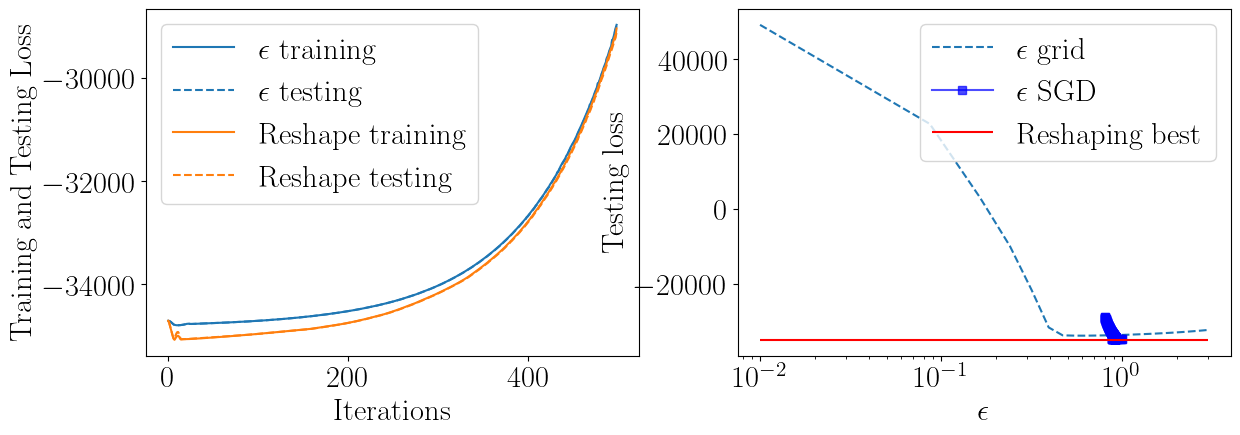

In [125]:

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(df_r2['step'], df_r2['Loss_val'], color="tab:blue", label=r"$\epsilon$ training")
ax1.plot(df_r2['step'], df_r2['Eval_val'], linestyle='--', color="tab:blue", label=r"$\epsilon$ testing")
ax1.plot(df1['step'], df1['Loss_val'], color="tab:orange", label="Reshape training")
ax1.plot(df1['step'], df1['Eval_val'], linestyle='--', color="tab:orange", label="Reshape testing")
ax1.legend()
ax1.set_xlabel("Iterations")
ax1.set_ylabel("Training and Testing Loss")

styles = ["s",'o',"^","v","<",">","o",'s',"^","v","<",">"]
j=0
ax2.plot(dfgrid["Eps"], dfgrid["Eval_val"], color = colors[j], linestyle='--',label="$\epsilon$ grid")
ax2.plot(df_r2["A_norm"],df_r2["Eval_val"], linestyle='-', marker=styles[j], color = "blue", label="$\epsilon$ SGD",alpha = 0.7)
ax2.hlines( xmin = np.min(dfgrid["Eps"]), xmax = np.max(dfgrid["Eps"]), y = np.min(df1["Eval_val"]), label = "Reshaping best", color= "red")   
ax2.set_xlabel("$\epsilon$")
ax2.set_ylabel("Testing loss")
ax2.set_xscale("log")
ax2.legend()
plt.show()


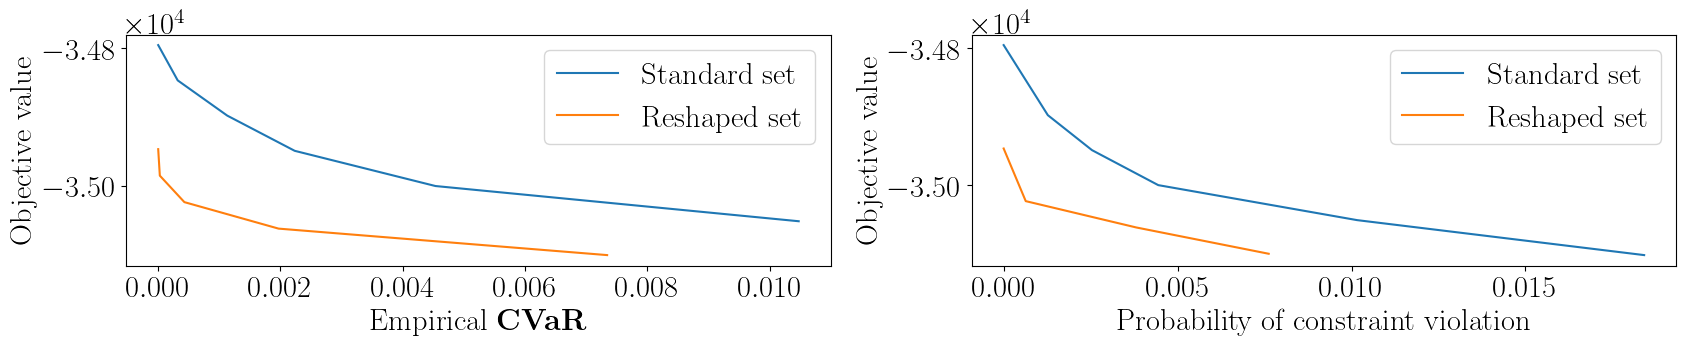

In [131]:
plt.rcParams.update({
    "text.usetex":True,
    
    "font.size":22,
    "font.family": "serif"
})

new = np.array(pareto_frontier(df1['Violations'][:500],df1['Test_val'][:500]))
orig = np.array(pareto_frontier(df_r2['Violations'][:500],df_r2['Test_val'][:500]))
new_ = np.array(pareto_frontier(dfgrid2['Violations'][:500],dfgrid2['Test_val'][:500]))
orig_ = np.array(pareto_frontier(dfgrid['Violations'][:500],dfgrid['Test_val'][:500]))


orig1 = np.array(pareto_frontier(df_r2['Violation_val'][:500],df_r2['Test_val'][:500]))
orig2= np.array(pareto_frontier(dfgrid['Violation_val'][:500],dfgrid['Test_val'][:500]))
new1 = np.array(pareto_frontier(df1['Violation_val'][:500],df1['Test_val'][:500]))
new2 = np.array(pareto_frontier(dfgrid2['Violation_val'][:500],dfgrid2['Test_val'][:500]))

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 3))
ax2.plot(orig_[0][:7], orig_[1][:7], color="tab:blue", label=r"Standard set")
# ax2.plot(df_r2['Violation_val'][:], df_r2['Test_val'][:]/1000, color="tab:blue", label=r"Learning $\epsilon$")
ax2.plot(new_[0][:4], new_[1][:4], color="tab:orange", label=r"Reshaped set")
# ax2.legend()?
# ax2.set_ylim([-35.98,-35.8])
ax2.set_xlabel("Probability of constraint violation")
ax2.set_ylabel("Objective value")
ax2.ticklabel_format(style="sci",axis='y',scilimits = (0,0), useMathText=True)

ax2.legend()


ax1.plot(orig2[0][:6], orig2[1][:6], color="tab:blue", label=r"Standard set")
# ax1.plot(df1['Violation_val'][:], df1['Test_val'][:]/1000, color="tab:orange", label=r"Learning $(A,b)$")

ax1.plot(new2[0][:5],new2[1][:5], color = "tab:orange",label=r"Reshaped set")
ax1.ticklabel_format(style="sci",axis='y',scilimits = (0,0), useMathText=True)

ax1.set_xlabel("Empirical $\mathbf{CVaR}$")
ax1.set_ylabel("Objective value")
# ax1.set_ylim([-35.98,-35.8])

ax1.legend()
plt.savefig("Inventory_val_2.pdf",bbox_inches='tight')
plt.show()


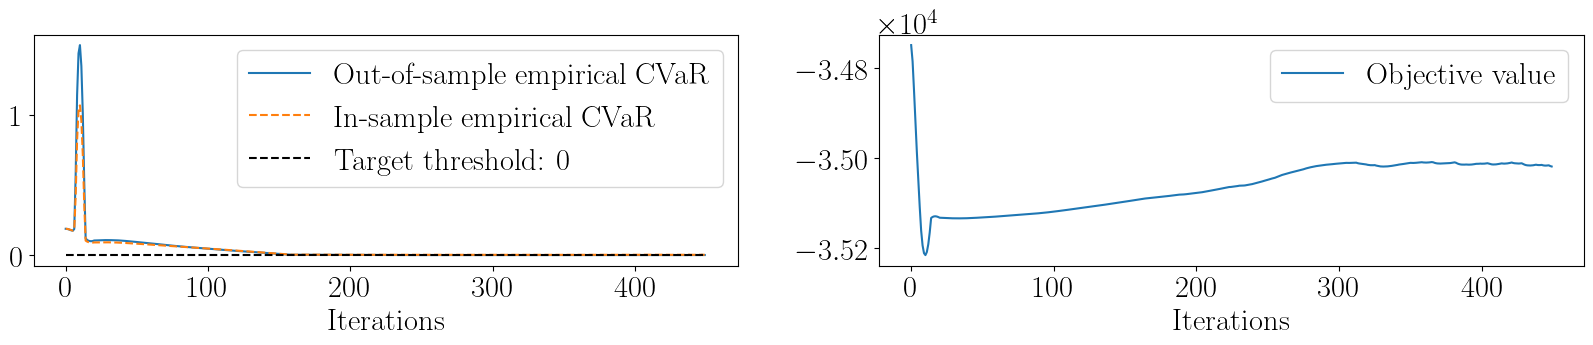

In [134]:
steps = 450
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 3))
ax1.plot(df1["Violation_val"][:steps], label = "Out-of-sample empirical CVaR")
ax1.plot(df1["Violation_train"][:steps], label = "In-sample empirical CVaR",linestyle = "--")

# ax1.set_ylabel("Empirical CVaR")
ax1.set_xlabel("Iterations")
ax1.hlines(xmin = 0, xmax = steps, y = -0.0, linestyles = "--",color = "black", label = "Target threshold: 0")
ax1.legend()

ax2.plot(df1["Test_val"][:steps], label = "Objective value")
# ax2.set_ylabel("Objective Value (k)")
ax2.set_xlabel("Iterations")
ax2.ticklabel_format(style="sci",axis='y',scilimits = (0,0), useMathText=True)

ax2.legend()
# ax2.set_ylim([-40000,-30000])
plt.savefig("Inventory_iters.pdf",bbox_inches='tight')

In [101]:
np.min(df1["Violation_val"])

0.0010458453144019002